In [1]:
import numpy as np
import fmm2dpy as fmm
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings

from hypermagnetics import plots
from hypermagnetics.sources import configure, configure_eval, _field_mt
from hypermagnetics.fmm_sources import potential2D

warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])


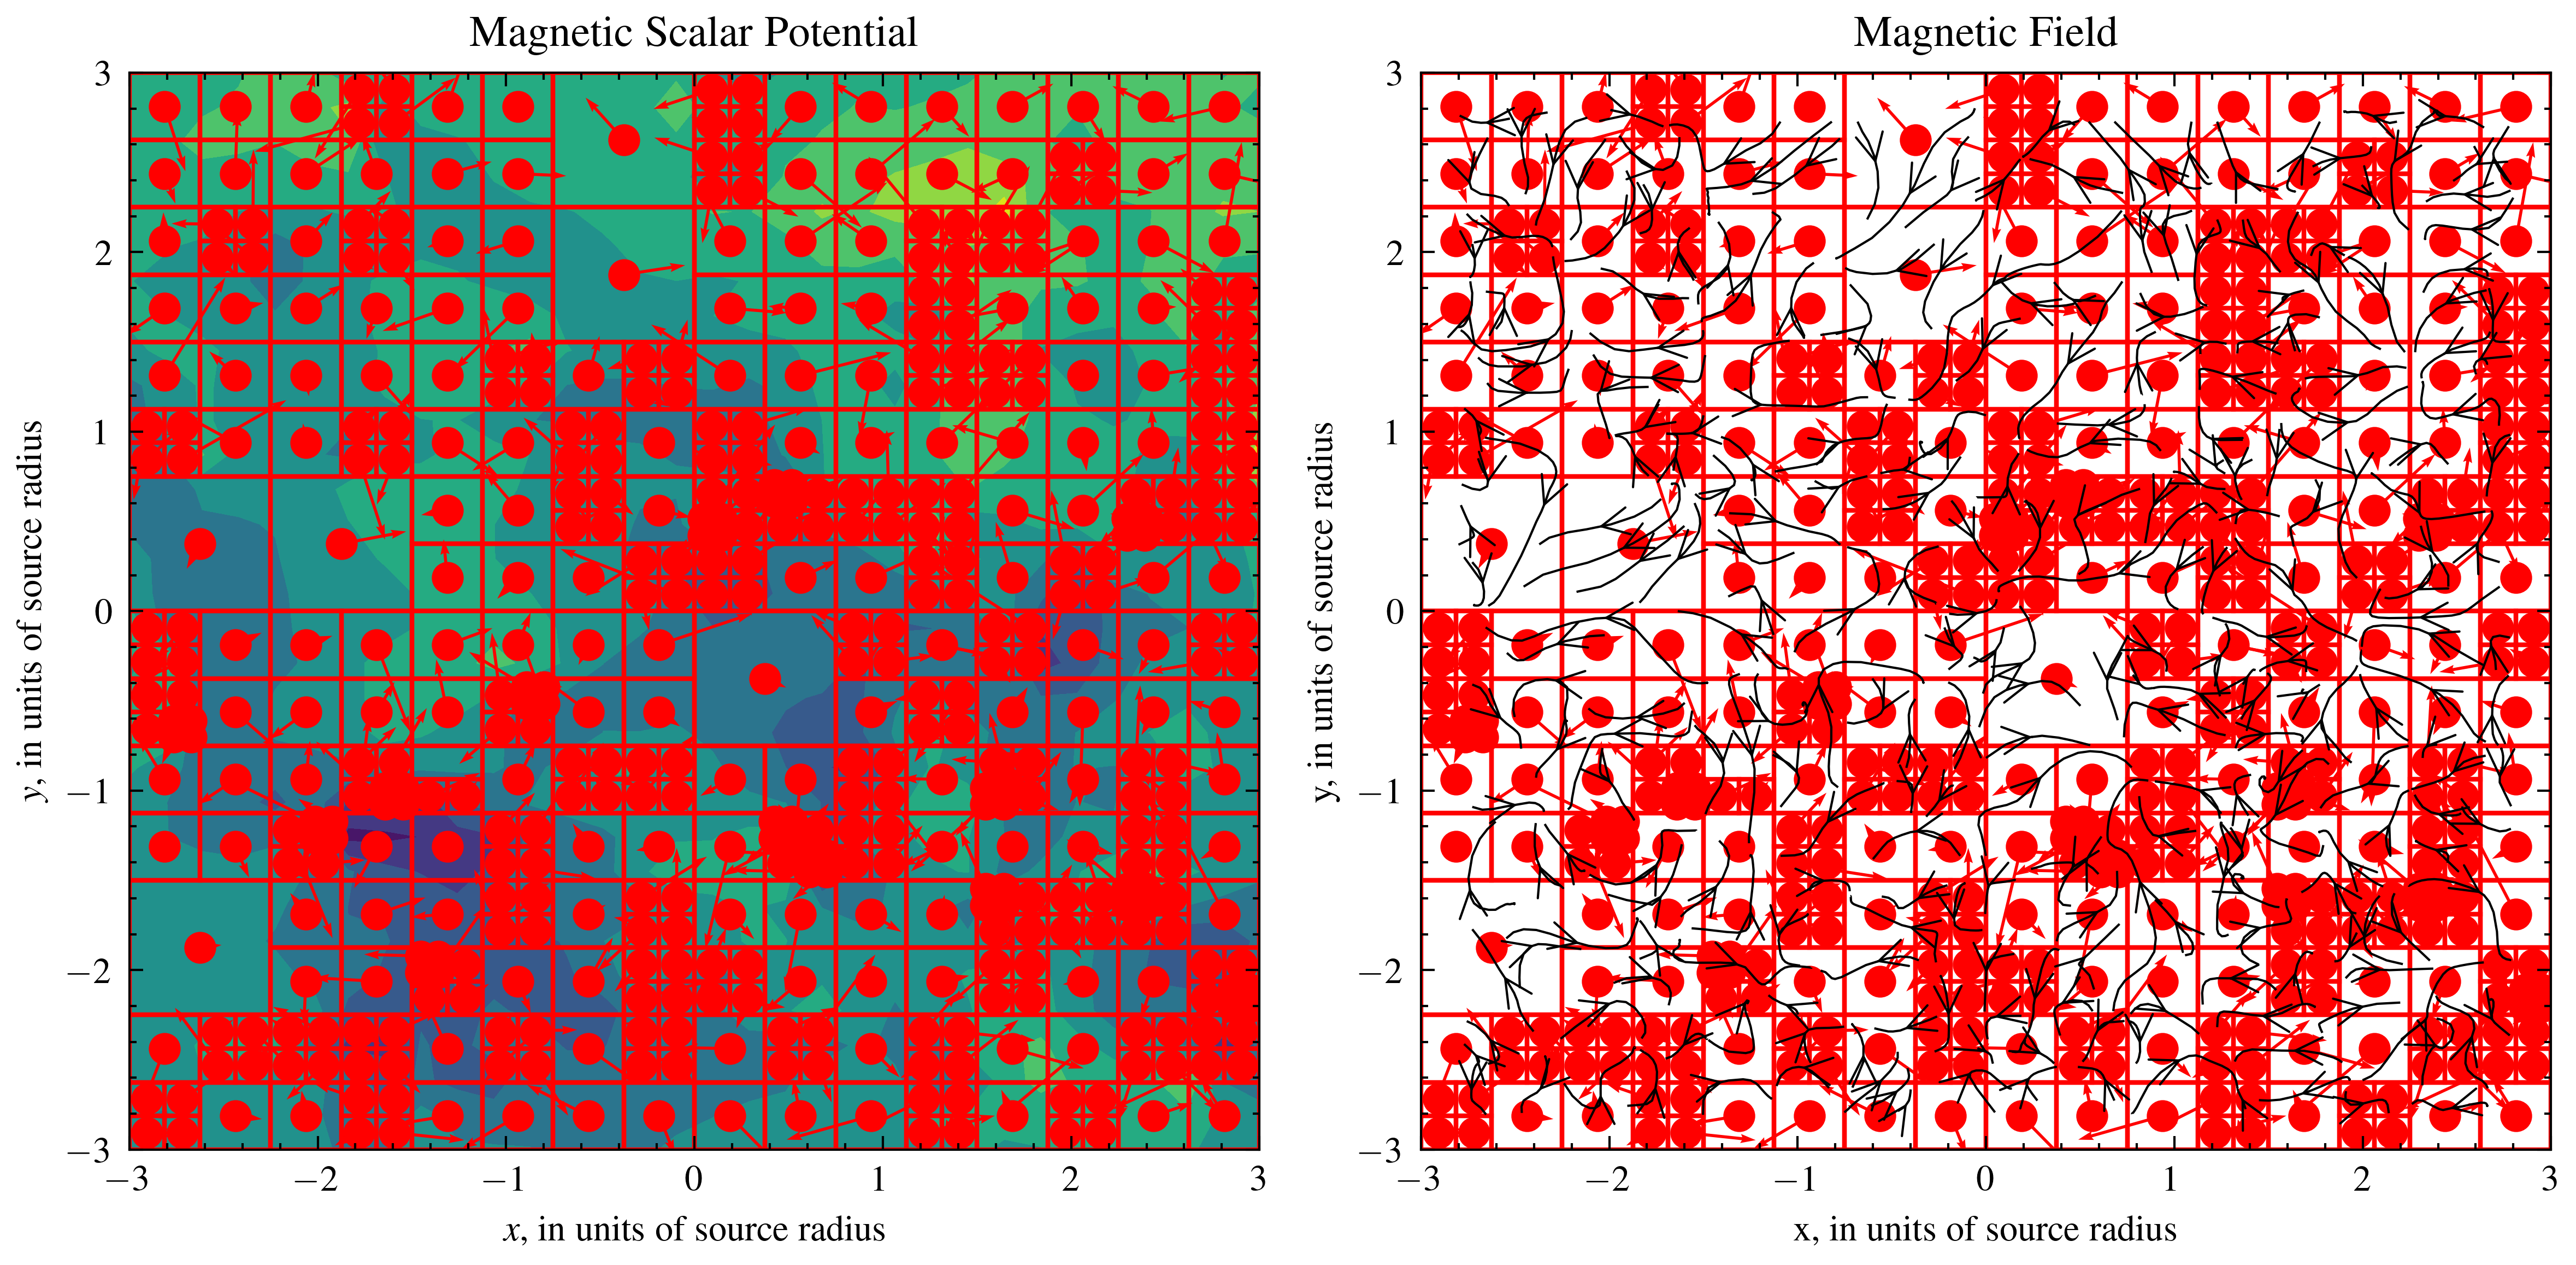

In [4]:
cfg = {
    "shape": "prism",
    "n_samples": 1,
    "lim": 3,
    # "source_val": False,
    # "eps": 0,
    # "eval": True,
    "quadtree": True
}
train = configure(**cfg, n_sources=500, seed=0)

# Test the fixed plotting function
plots(train, source=True, shapes=True)

# x_grid = np.array(train['grid'][:, 0].reshape((cfg["res"], cfg["res"])))
# y_grid = np.array(train['grid'][:, 1].reshape((cfg["res"], cfg["res"])))
# target_f = train["field_grid"][0 : 1, ..., 0].reshape((len(train["sources"][0 : 1]), cfg["res"], cfg["res"]))
# plt.contourf(x_grid, y_grid, np.clip(target_f[0], -3.2, 3.2))
# plt.colorbar()

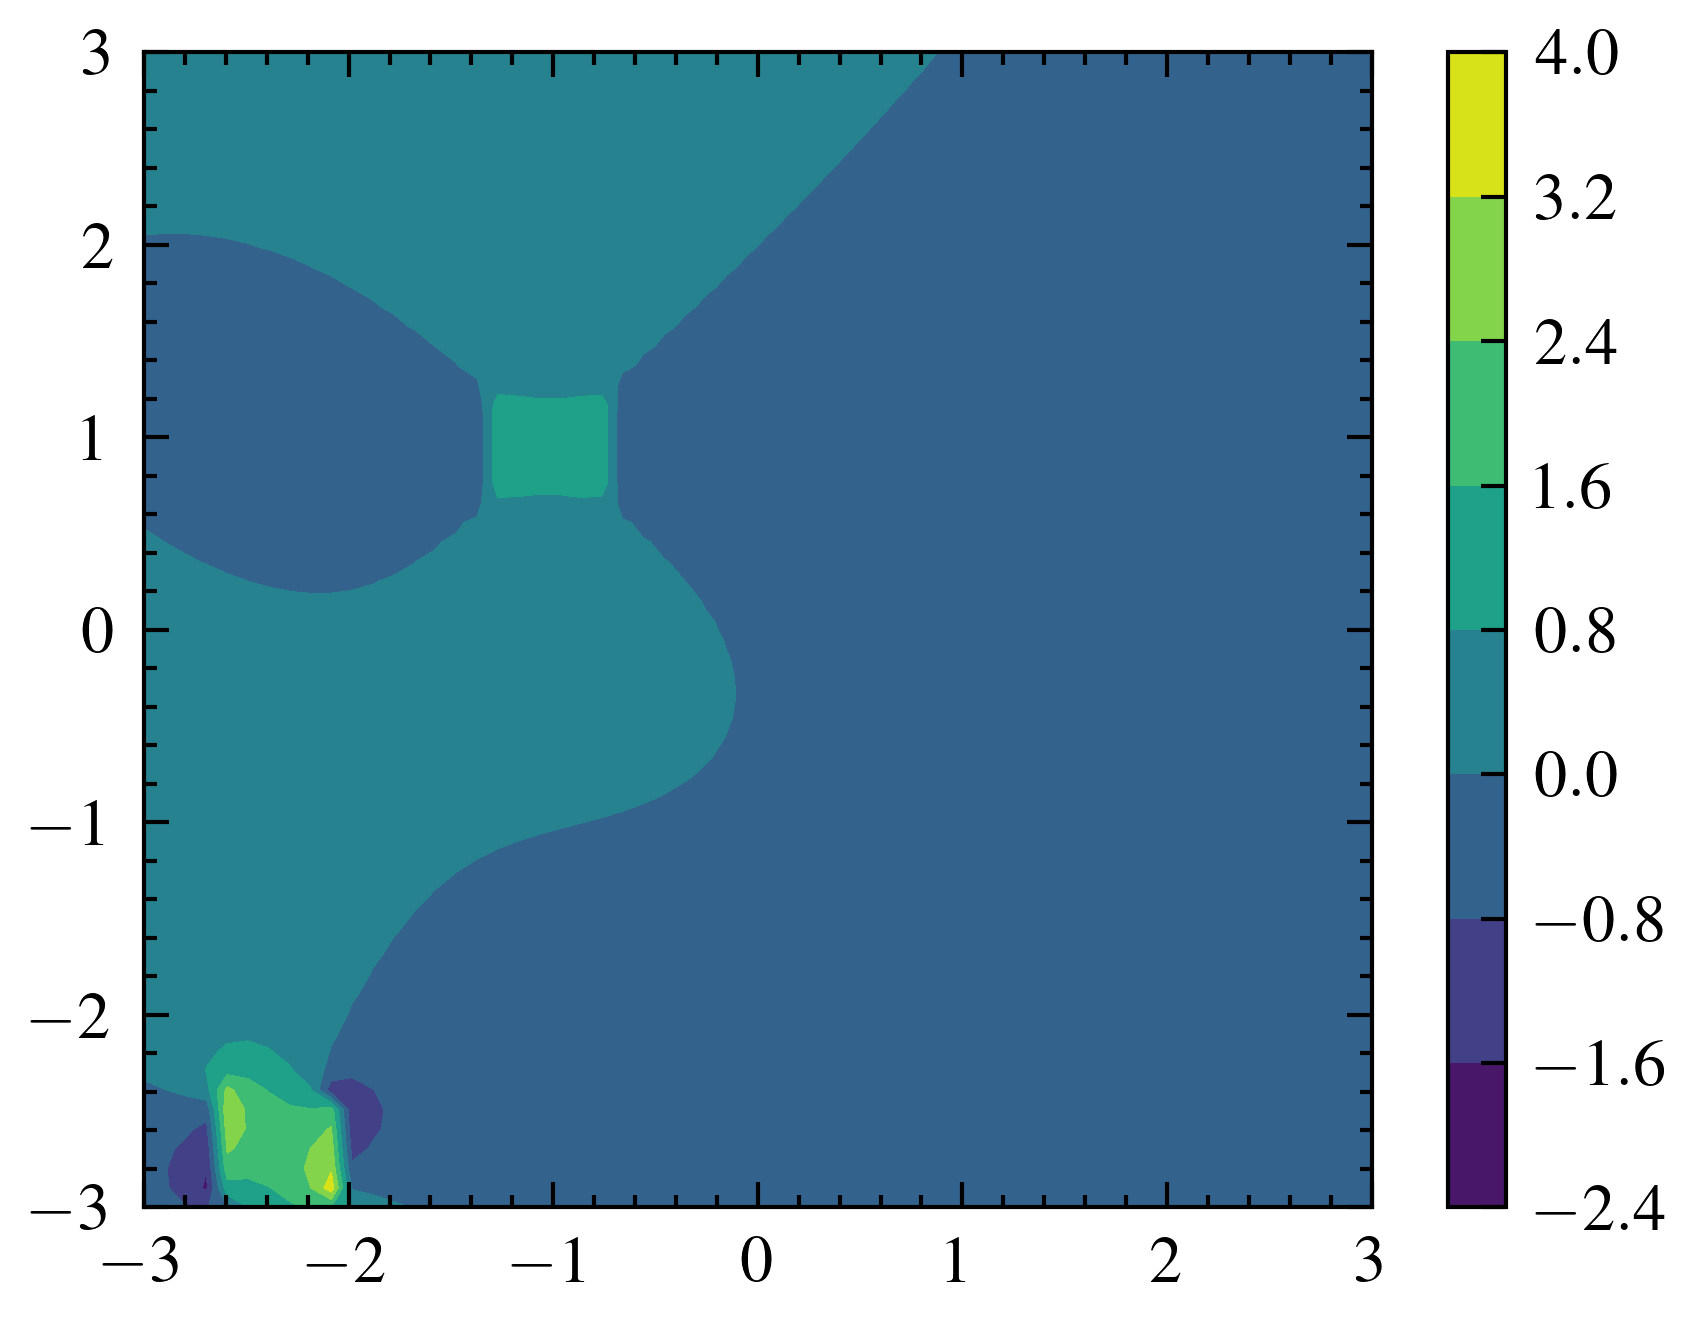

In [4]:
mt_sim, _ = _field_mt(train['sources'], train['grid'], "prism")

x_grid = np.array(train['grid'][:, 0].reshape((cfg["res"], cfg["res"])))
y_grid = np.array(train['grid'][:, 1].reshape((cfg["res"], cfg["res"])))
mt_field = mt_sim[0, ..., :2].reshape((cfg["res"], cfg["res"], 2))
plt.contourf(x_grid, y_grid, mt_field[..., 0])
plt.colorbar()